# Exercise Sheet: Machine Learning with the California Housing Dataset

Duration: ~4 hours

Level: Master’s (physics / data science)

Tools: Python, pandas, matplotlib, scikit-learn


## Learning goals

By the end of this session, you should be able to:

- Load and explore real-world datasets
- Understand feature distributions and correlations
- Prepare data for machine learning
- Train and evaluate regression models
- Interpret model performance and limitations

## Part 0 - Setup (15 min)
Exercise 0.1 - Download and load the dataset

Use the provided code to:

- Download the dataset
- Extract it
- Load it into a pandas DataFrame

### Task

Print the first 5 rows
Check the shape of the dataset

In [1]:
import os
import tarfile
import urllib.request
import pandas as pd

url_h = "https://github.com/ageron/data/raw/main/housing.tgz"

download_dir = "datasets"
tgz_path = os.path.join(download_dir, "housing.tgz")
extract_dir = os.path.join(download_dir, "housing")

def down_extr(url = url_h, tgz_path = tgz_path, extract_dir = extract_dir):
    os.makedirs(download_dir, exist_ok=True)

    if not os.path.exists(tgz_path):
        print("Downloading dataset...")
        urllib.request.urlretrieve(url,tgz_path)
        print("Download complete."  )
    else:
        print("Dataset already downloaded")

    if not os.path.exists(extract_dir):
        print("Extracting files...")
        with tarfile.open(tgz_path) as tar:
            tar.extractall(path=download_dir)   
        print("Estraction complete.")
    else:
        print("Files alrealdy extracted.")

def csv_to_pandas(csv_path = os.path.join(extract_dir,"housing.csv")):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(
            f"Csv file not found in {csv_path}"
            "Make sure the dataset is downloaded and extracted"
        )
    print("Loading dataset inno pandas DataFrame...")
    df = pd.read_csv(csv_path)

    return df


down_extr()

housing_df = csv_to_pandas()

housing_df.head()


Dataset already downloaded
Files alrealdy extracted.
Loading dataset inno pandas DataFrame...


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Exercise 0.2 — Basic inspection

Questions

- How many features are there?
- What are their names?
- Which feature is the target variable?



We can check for `ocean_proximity` since its type is object, while others are numerical

We can check the summary of the numerical attributes

## Part 1 — Data Exploration (45 min)

### Exercise 1.1 — Visualizing distributions

Plot histograms of all features:

Questions

- Which variables are skewed?
- Are there outliers?
- Which feature looks discretized?

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

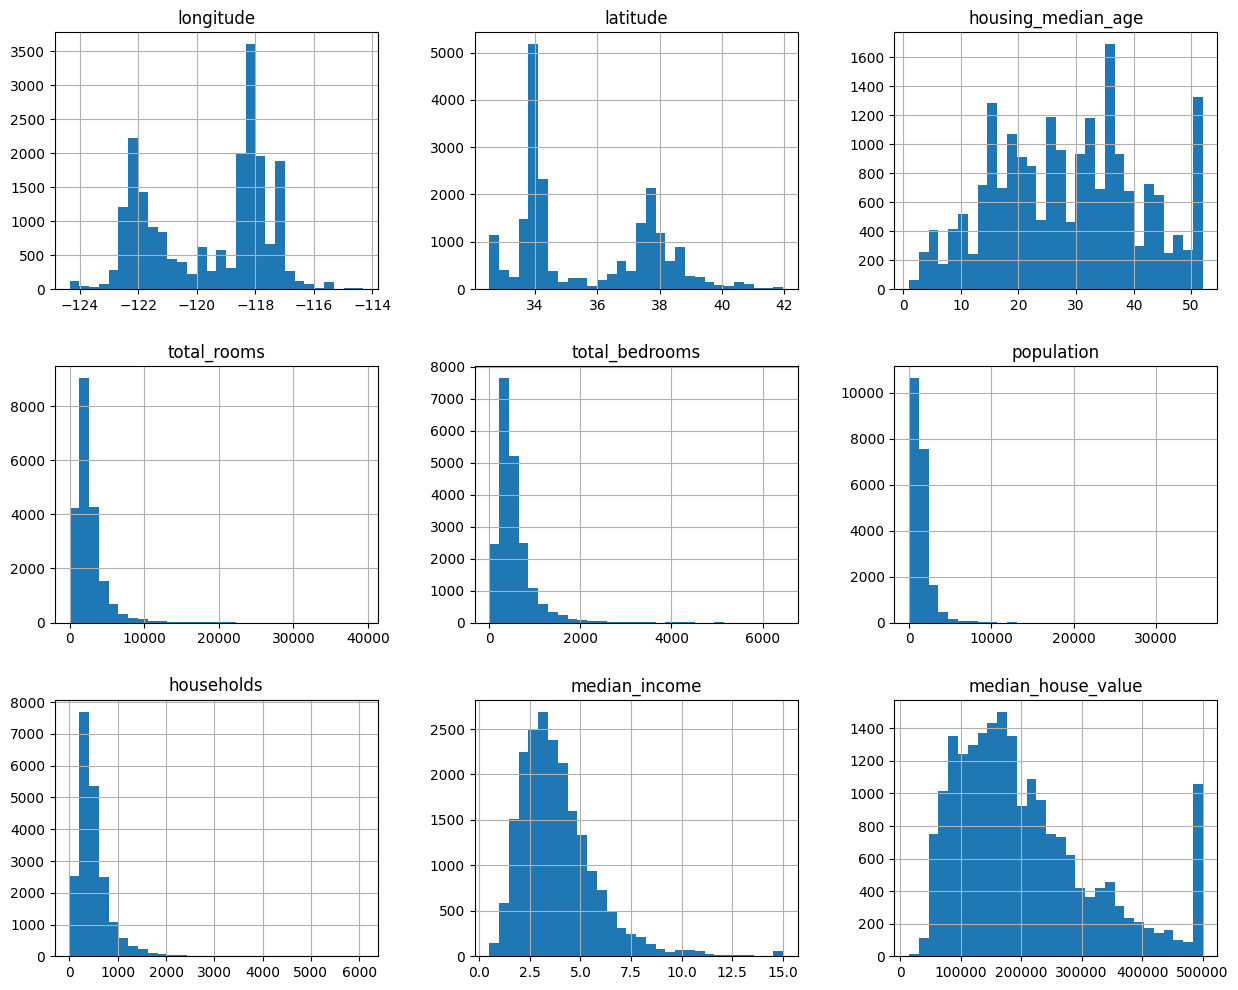

In [2]:
housing_df.hist(bins=30,figsize=(15,12))

### Exercise 1.2 — Geographic visualization

Plot longitude vs latitude (both simple and with some beautiful colours):

Questions

- Where are the most expensive houses located?
- What patterns do you see?

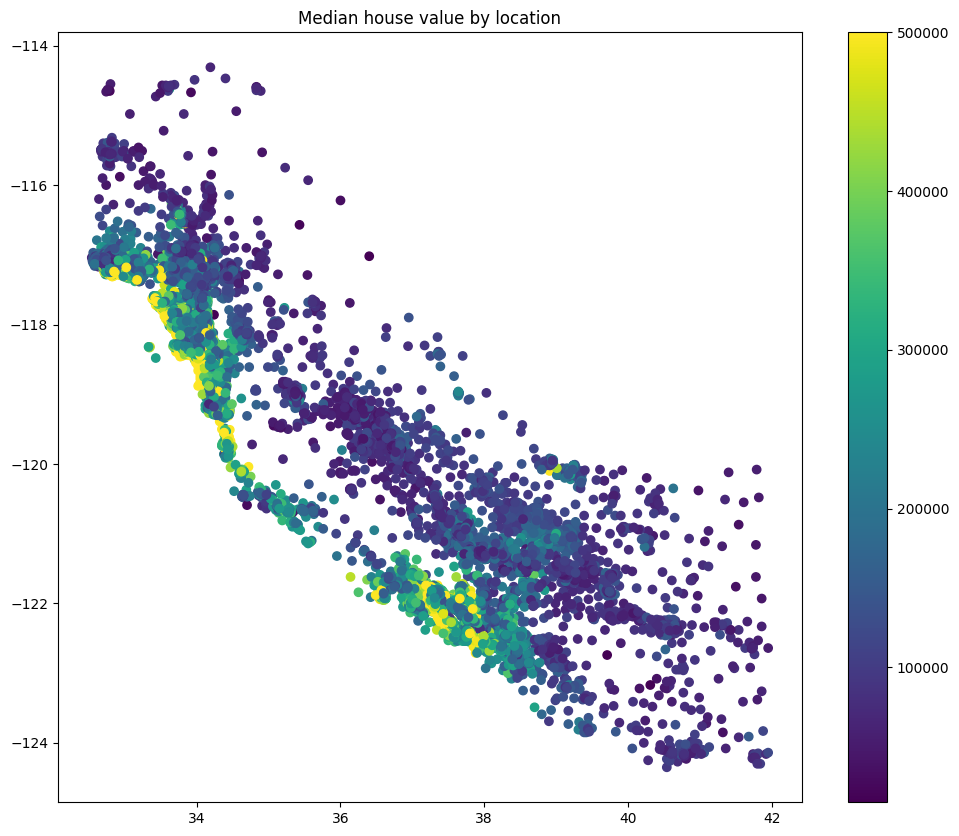

In [3]:
import matplotlib.pyplot as plt 

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot()

sc = ax.scatter(
            housing_df.latitude, 
           housing_df.longitude,
           c=housing_df.median_house_value
)   
fig.colorbar(sc)
ax.set_title("Median house value by location")

plt.show()

### Exercise 1.3 — Correlation analysis

Compute correlation matrix:

Task

Find the features most correlated with median_house_value

Question

Which variable is the strongest predictor?

In [4]:
numeric_df = housing_df.select_dtypes(include='number')
categorial_df = housing_df.select_dtypes(exclude='number')

numeric_df.corr()
numeric_df.corr()['median_house_value'].sort_values(ascending=False)



median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## Part 2 - Data Preparation (60 min)
### Exercise 2.1 - Train/test split

Split data:

Question

Why do we split the dataset?

In [5]:

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


income_category = pd.cut(housing_df.median_income, bins=5)


x = housing_df.drop("median_house_value", axis=1)
y = housing_df.median_house_value

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42,stratify=income_category)

num_cols = x_train.select_dtypes(include="number").columns
cat_cols = x_train.select_dtypes(exclude="number").columns

x_train_num = x_train[num_cols]
x_test_num = x_test[num_cols]

x_train_cat = x_train[cat_cols]
x_test_cat = x_test[cat_cols]


imputer = SimpleImputer(strategy="median")

x_train_num = imputer.fit_transform(x_train_num)
x_test_num = imputer.transform(x_test_num)
    

# Convert back to DataFrame with original column names
x_train_num = pd.DataFrame(x_train_num, columns=num_cols, index=x_train.index)
x_test_num = pd.DataFrame(x_test_num, columns=num_cols, index=x_test.index)



encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

x_train_cat = encoder.fit_transform(x_train_cat)
x_test_cat = encoder.transform(x_test_cat)

# Get encoded column names
encoded_cols = encoder.get_feature_names_out(cat_cols)

# Convert back to DataFrame
x_train_cat = pd.DataFrame(
    x_train_cat,
    columns=encoded_cols,
    index=x_train.index
)

x_test_cat = pd.DataFrame(
    x_test_cat,
    columns=encoded_cols,
    index=x_test.index
)

x_train = pd.concat([x_train_num, x_train_cat], axis=1)
x_test = pd.concat([x_test_num, x_test_cat], axis=1)

# -----------------------------
# Feature engineering
# -----------------------------
for df in [x_train, x_test]:
    df["rooms_per_household"] = (
        df["total_rooms"] / df["households"]
    )

    df["bedrooms_per_room"] = (
        df["total_bedrooms"] / df["total_rooms"]
    )

    df["population_per_household"] = (
        df["population"] / df["households"]
    )

# def scal(x_train_num=x_train, x_test_num=x_test):
#     scaler =  StandardScaler()
#     x_train_scaled = scaler.fit_transform(x_train_num)
#     x_test_scaled = scaler.transform(x_test_num)
#     return x_train_scaled, x_test_scaled

# x_train, x_test= scal()


### Exercise 2.2 — Stratified sampling

Create income categories:

Plot it

What is stratified sampling (intuition)

Instead of splitting your dataset randomly, you split it in a way that preserves the distribution of an important variable.

In this dataset, that variable is:
`median_income`

Why do we care here?

House prices depend strongly on income.

If you do a purely random split:

- you might accidentally get too many rich districts in train
- and too many poor districts in test

Result: your model evaluation becomes biased / unreliable

### Exercise 2.3 — Handling missing values

Identify missing values:

### Exercise 2.4 — Feature engineering

Create new features:

Question

Why might these features help?

### Exercise 2.5 — Categorical variables

Encode ocean_proximity:

## Part 3 - Linear Regression

### Exercise 3.1 — Look at a few predictions

New cell

Questions for students

- Are the predictions close to the true values?
- Does the model always overestimate, always underestimate, or both?
- Are there cases where the prediction error is very large?

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression

model = LinearRegression()


model.fit(x_train, y_train)

y_pred = pd.Series(model.predict(x_test), index=y_test.index)


residuals = y_test - y_pred

# print(y_pred.head(10))
# print(y_test.head(10))

print(y_train.describe())
residuals.describe()


count     16512.000000
mean     206875.973232
std      115499.720137
min       14999.000000
25%      119400.000000
50%      179500.000000
75%      265000.000000
max      500001.000000
Name: median_house_value, dtype: float64


count      4128.000000
mean       -223.311013
std       68797.245047
min     -361364.159726
25%      -43318.514385
50%      -10641.659090
75%       29562.930563
max      348519.589604
dtype: float64

### Exercise 3.2 — Compute residuals

Explain that the residual is: $$ residual = y_{true} - y_{cell}$$



Questions

- What does a positive residual mean?
- What does a negative residual mean?
- If residuals are centered around zero, what does that suggest?

Questions

- What is the mean residual?
- Is it close to zero?
- What is the standard deviation of the residuals?

### Exercise 3.4 — Plot true vs predicted values

This is one of the best linear-regression exercises.

Questions

- What would a perfect model look like on this plot?
- Do the points follow the diagonal?
- In which region does the model perform worse?

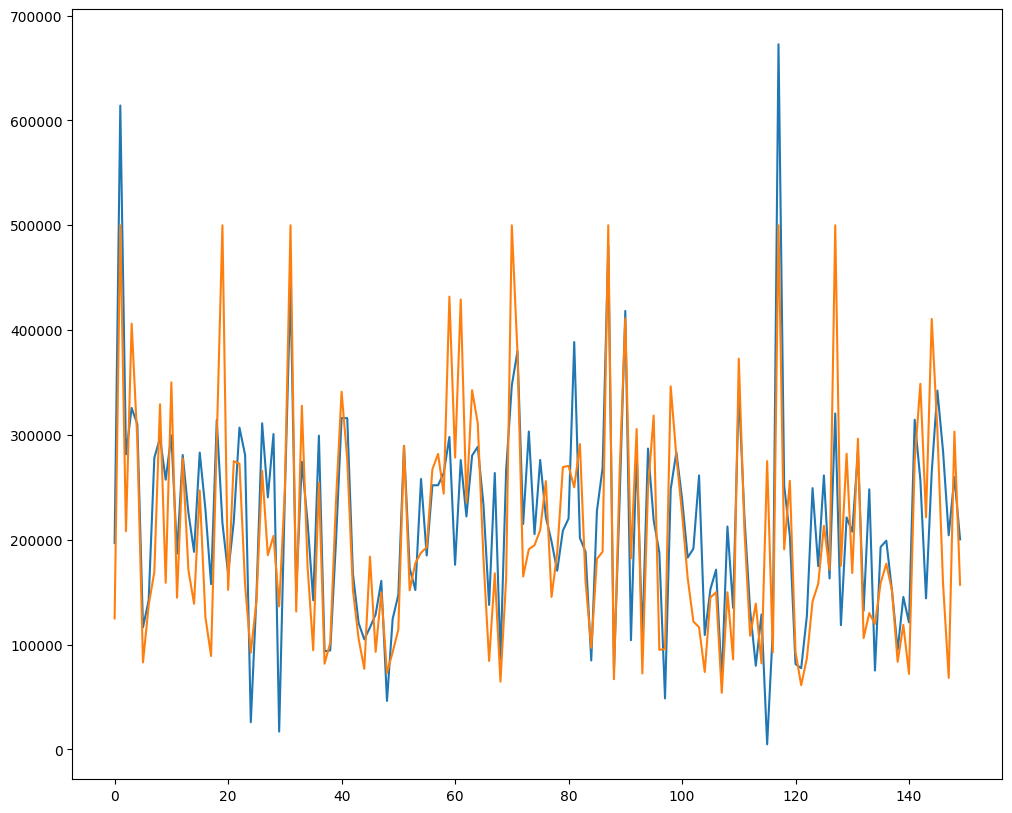

In [7]:
fig , ax = plt.subplots(figsize = (12,10))

ax.plot(y_pred.to_numpy()[:150])
ax.plot(y_test.to_numpy()[:150])


### Exercise 3.9 — Standardize the numerical variables and retrain

Still linear regression, but now you learn why preprocessing matters.